In [17]:
## THIS WILL BE CHANGED TO FROM SOLER.PY IMPORT *
## TO DO FINISH ADDING INFO
from run_any_data import *

# Notebook to plot and fit SEP data
#### General information about the notebook:
This Notebook allows the user to load, plot and fit SEP energy spectra. The fitting is done using Python ODR.
The data loading process uses solo-epd-loader. (TO DO: CHANGE DEPENDING ON THE ROUTINE)
<br>This package can be installed simply by running   %pip install git+https://github.com/jgieseler/solo-epd-loader    in any cell of the notebook. Note that this should only be done once. The package can be updated by running: %pip install git+https://github.com/jgieseler/solo-epd-loader --upgrade
<br>The data will be saved as cdf files to a local folder provided by the user. The data is then used to create dataframes of the electron data for each instrument and energy channel. 
<br>The flux data will be plotted as a timeseries. The timeseries include all the energy channels for each instrument. (add  expl pa) A flux peak will be searchered for each energy channel using the provided injection time and following the velocity dispersion. These values will then be plotted against the energy corresponding to the channels to form a spectrum. 
<br>The spectrum can then be fit with various functions to analyse its shape.

## Loading the data files

#### NOTE: to use the fitting function you need to provide the uncertainty for both x- and y-data (e.g. energy and flux).  NOTE2: this will be changed so that there is no need fot the uncertainties

<br> provide the path to the file. The file can be in either txt or csv format. If the data is in xlsx format use pd.read_excel() instead of pd.read_csv()


In [2]:
#path_to_file = r'C:/Users/Omistaja/Desktop/SRL/2021SRL/messenger/event1.txt'
path =  r'/home/annafed/Documents/SOLER/spectrum_slices_start_2021-10-28_15_00_00_step_60.0min_SOLO_EPT_sun_ions_0.csv'
data = pd.read_csv(path) # or pd.read_excel() for xlsx data


#### Choose what to fit. The file can contain all kinds of data and multiple columns etc. Below, you need to choose what you want to fit. Choose x-axis data and y-axis data. 

In [3]:
#THIS WILL BE MADE INTO A FUNCTION IN THE BG THIS IS AN OLD ROUTINE

x_data = data['Energy']
y_data = data['Intensity']
#x_err = data['name of column with x uncertainty data'] 
#y_err = data['name of column with y uncertainty data']

# if the data doesn't contain uncertainty it still needs to be provided for the fitting functions to works
# e.g. use 10% of the data 
# This will be changed

x_err = data['E_err']
y_err = data['I_err']


## Saving data 
#### You can choose to save the plot (savefig), the ODR run as a pickle file (save_pickle) and save all the variables from the fitting procedure (save_fit_variables) by setting the options below to True

In [4]:
savefig = False # save the fit
save_pickle = False # save a pickle file of the odr run
save_fit_variables = False # save the variables from the fit

In [5]:
data_for_the_fit = pd.DataFrame()
data_for_the_fit['x'] = x_data
data_for_the_fit['y'] = y_data
data_for_the_fit['x error'] = x_err
data_for_the_fit['y error'] = y_err

data_for_the_fit_list = [data_for_the_fit]

In [6]:
data_for_the_fit

,x,y,x error,y error
0,0.053328,NaN,0.003965,NaN
1,0.055929,2904.198700,0.004110,3095.091000
2,0.058856,1324.926100,0.003745,1447.016500
3,0.061322,1486.809900,0.003640,1599.075100
4,0.064197,1013.052200,0.003545,1076.381100
...,...,...,...,...
59,4.286448,0.564311,0.191410,0.564311
60,4.672104,-0.015804,0.194000,0.015804
61,5.087562,0.486875,0.222285,0.486875
62,5.567431,-0.023466,0.258740,0.023466


## INPUTS FOR THE FIT

### which_fit options: 
<br>'single' will force a single pl fit to the data
<br> 'broken' will force a broken pl fit to the data but ONLY if the break point is within the energy range otherwise a sigle pl fit will be produced instead
<br> 'best_sb' will choose automatically the best fit type between single and broken by comparing the redchis of the fits
<br> 'cut' will produce a single pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken or single pl will be fit instead
<br> 'broken_cut' will produce a broken pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken or single pl will be fit instead
<br> 'best_cb' will choose the better option between a broken pl and a single+cutoff. If the break and cutoff points are outside of the energy range a single pl will be fit instead.
<br>'triple' will try to fit a triple pl. If not possible, will try to fit the next best option.
<br> 'best' will choose automatically the best fit type by comparing the redchis of the fits


In [8]:
which_fit = 'best' 

## Guess values and energy range
#### NOTE: e_min, e_max, break_guess and cut_guess should bein MeV. e_min and e_max can also be None. In this case the MAKE_THE_FIT function will automaically choose the values. (energy on x-axis)

<br>Random and iterations
<br>if use_random = False the fit will only be made once with the guess values
<br> if use_random = True the fitting function will first create a list of reasonable values for each of the fitting parameters then randomly select values from the lists and compare the redchis of each fit to find the best one
<br> iterations = number of times the fit is retried to find the best one

In [13]:
e_min =  None # in MeV 
e_max = None# in MeV

g1_guess = -1.9 # gamma 1 -> spectral index before the break (or single pl)
g2_guess = -2.5 # gamma 2 -> spectral index after the break (for broken pl)
g3_guess = -4.5 # gamma 3 -> spectral index after the second break (for triple pl)
c1_guess = 1e3 # peak flux
alpha_guess = 7.16 # sharpness of the first break
beta_guess = 10 #sharpness of the second break
break_guess_low = 0.06 #in MeV
break_guess_high = 0.12
cut_guess = 0.12 #in MeV

#legend_details = False

use_random = True 
iterations = 20

which_fit = 'broken' 

In [14]:
plot_title = 'SOLER DATA TEST'
x_label = 'Energy (MeV)'
y_label = 'Intensity\n/(s cm² sr MeV)'
legend_title = '' 

           x            y   x error      y error
0   0.053328          NaN  0.003965          NaN
1   0.055929  2904.198700  0.004110  3095.091000
2   0.058856  1324.926100  0.003745  1447.016500
3   0.061322  1486.809900  0.003640  1599.075100
4   0.064197  1013.052200  0.003545  1076.381100
5   0.068088   931.730350  0.003635   988.059270
6   0.072282   772.946900  0.003455   831.749400
7   0.076269   433.466860  0.003415   472.801120
8   0.080047   714.069400  0.003295   769.206240
9   0.083889   511.748020  0.003055   546.600100
10  0.089144   433.926100  0.002170   484.544770
11  0.094331   583.450400  0.003040   605.597100
12  0.100346   501.543700  0.002970   543.151250
13  0.106454   149.342900  0.003140   172.613280
14  0.113391   344.709300  0.003815   367.300930
15  0.120884   350.950070  0.003670   379.441250
16  0.128896   302.497400  0.004360   323.098660
17  0.137543   564.238040  0.004280   578.373000
18  0.146563   256.224760  0.004750   271.715150
19  0.157006   210.6

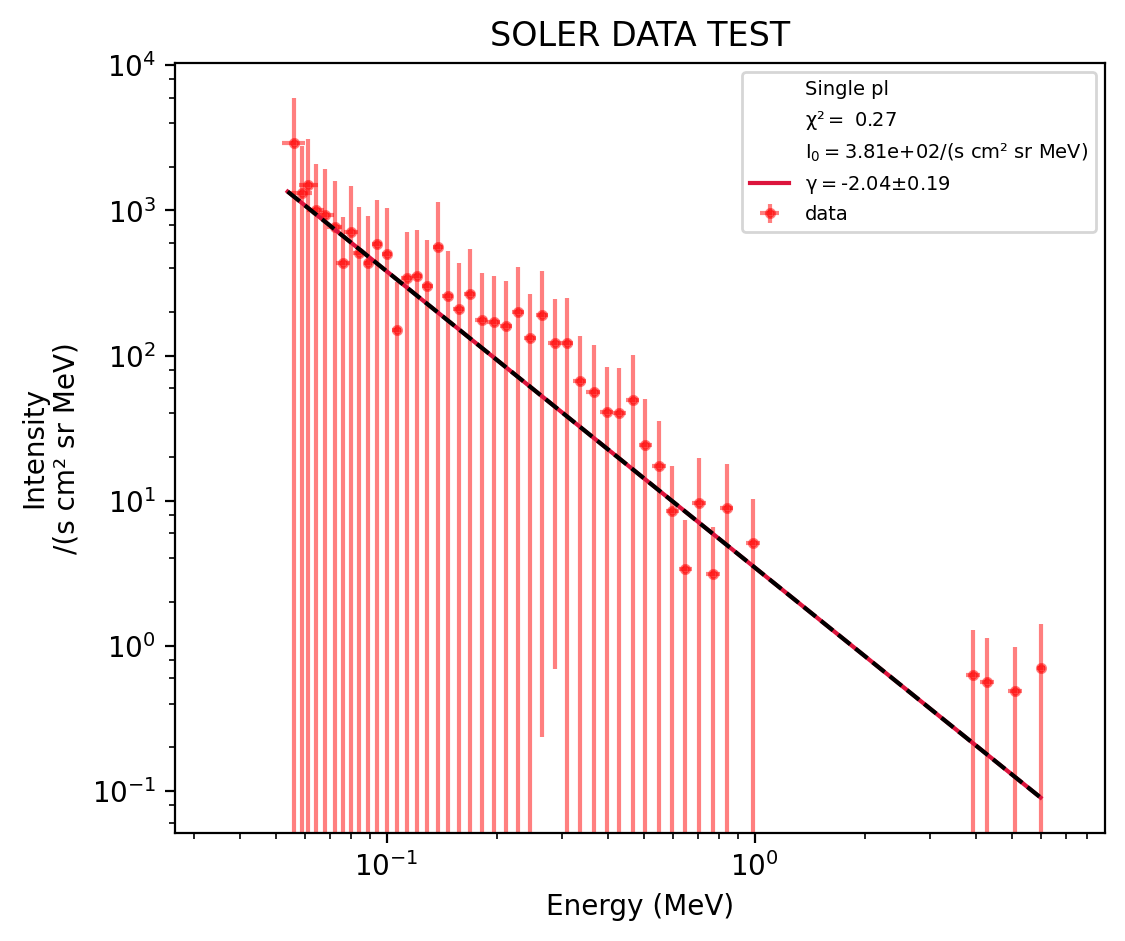

In [15]:
# WILL ADD THE PRINT FOR THE FIT VALUES ETC
run_all(path, data_for_the_fit_list, savefig = True, plot_title = plot_title, x_label = x_label, y_label = y_label, legend_title = legend_title, which_fit = 'single',  e_min = e_min, e_max = e_max, g1_guess =g1_guess, g2_guess = g2_guess, g3_guess = g3_guess, c1_guess = c1_guess, alpha_guess = alpha_guess, beta_guess = beta_guess, break_guess_low = break_guess_low, break_guess_high = break_guess_high, cut_guess = cut_guess, use_random = use_random, iterations = iterations , legend_details = True)
            # data, savefig, plot_title = '', x_label = 'Intensity [/]', y_label = 'Energy [MeV]', legend_title = '', data_label_for_legend = ['data'], which_fit = 'best', e_min = None, e_max = None, g1_guess = -1.9, g2_guess = -2.5, g3_guess = -4, c1_guess = 1000, alpha_guess = 10, beta_guess = 10, break_guess_low = 0.6, break_guess_high = 1.2, cut_guess = 1.2, use_random = True, iterations = 20 , legend_details = False):
    